> **Superseded exploratory notebook** — groundwork for secondary-dataset enrichment (Amazon rank, UCSD, adaptations). Not part of the final modelling pipeline; see `EDA/book_success_merge.ipynb` and `methodology/design.md` for the canonical pipeline.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, re
if os.path.basename(os.getcwd()) == 'scripts_local':
    sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.io import (
    load_goodbooks, load_amazon_popular, load_amazon_rank_index,
    load_nyt_bestsellers, load_books_into_movies, load_ucsd_filtered,
)
from utils.joining import (
    normalize_isbn13, normalize_isbn10, isbn10_to_isbn13,
    normalize_title, normalize_author,
    join_on_isbn10, join_on_isbn13, join_on_title_author, agg_nyt_bestsellers,
)
from utils.rank_features import batch_compute_rank_features, available_rank_asins
from utils.plotting import apply_style, save_fig, coverage_bar, COLOR_PALETTE
from utils import paths

apply_style()
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

# Override to save derived outputs to external drive:
#   paths.DERIVED_ROOT = paths.EXTERNAL_DATA_ROOT
print('Saving derived outputs to:', paths.DERIVED_ROOT)

Saving derived outputs to: /Users/dingshandeng/data_local/data_book


## Step 1 — GoodBooks Base Table
10,000 books with ratings, genres, descriptions, and ISBNs. This is the spine everything else joins to.

**Why ISBNs give limited coverage across datasets:**  
An ISBN identifies one specific *edition* — hardcover ≠ paperback ≠ ebook. The same title can have 5–10  
different ISBNs. NYT tracks the hardcover edition ISBN; GoodBooks stores whichever edition Goodreads  
canonised; Amazon rank files use ASINs (which equal ISBN-10 for print books, but edition-specific).  
Title+author matching is used as a universal fallback because it is edition-agnostic.

In [2]:
gb = load_goodbooks()

gb['isbn10'] = gb['isbn'].apply(normalize_isbn10)
gb['isbn13'] = gb['isbn13'].apply(normalize_isbn13)

# Fill isbn13 from isbn10 where missing
mask = gb['isbn13'].isna() & gb['isbn10'].notna()
gb.loc[mask, 'isbn13'] = gb.loc[mask, 'isbn10'].apply(isbn10_to_isbn13)

BASE_COLS = [
    'book_id', 'title', 'authors', 'original_publication_year',
    'language_code', 'pages', 'description', 'genres',
    'isbn10', 'isbn13', 'goodreads_book_id',
    'average_rating', 'ratings_count', 'work_text_reviews_count',
    'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5',
]
canon = gb[[c for c in BASE_COLS if c in gb.columns]].copy()

print(f'Base table: {canon.shape}')
print(f'isbn10: {canon["isbn10"].notna().sum():,} / {len(canon):,}')
print(f'isbn13: {canon["isbn13"].notna().sum():,} / {len(canon):,}')
canon.head(3)

Base table: (10000, 19)
isbn10: 9,300 / 10,000
isbn13: 9,435 / 10,000


,book_id,title,authors,original_publication_year,language_code,pages,description,genres,isbn10,isbn13,goodreads_book_id,average_rating,ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
0,1,"The Hunger Games (The Hunger Games, #1)",[Suzanne Collins],2008.0,eng,374.0,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES HAVE BEGUN. . . .In the ruins of a place ...,"[young-adult, fiction, fantasy, science-fiction, romance]",0439023483,9780439023480,2767052,4.34,4780653,155254,66715,127936,560092,1481305,2706317
1,2,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","[J.K. Rowling, Mary GrandPré]",1997.0,eng,309.0,"Harry Potter's life is miserable. His parents are dead and he's stuck with his heartless relatives, who force him to...","[fantasy, fiction, young-adult, classics]",0439554934,9780439554930,3,4.44,4602479,75867,75504,101676,455024,1156318,3011543
2,3,"Twilight (Twilight, #1)",[Stephenie Meyer],2005.0,eng,501.0,"About three things I was absolutely positive.\n\nFirst, Edward was a vampire.\n\nSecond, there was a part of him—and...","[young-adult, fantasy, romance, fiction, paranormal]",0316015849,9780316015840,41865,3.57,3866839,95009,456191,436802,793319,875073,1355439


## Step 2 — Amazon Popular: Price & Rating Data
Source: ~2,269 popular books on Amazon UK with price, review count, and star rating.

The `ISBN10` column is *mixed*: some rows carry a proper 10-digit ISBN-10, others accidentally  
contain a 13-digit ISBN-13.  We detect and handle both, then cascade:  
**ISBN-10 → ISBN-13 → title+author**.

In [3]:
amz = load_amazon_popular()

# Separate the mixed ISBN10 column into explicit isbn10 / isbn13
def _split_amz_isbn(raw):
    if pd.isna(raw):
        return pd.Series({'_amz_isbn10': None, '_amz_isbn13': None})
    s = re.sub(r'[^0-9X]', '', str(raw).split('.')[0].upper())
    if len(s) == 10:
        return pd.Series({'_amz_isbn10': s, '_amz_isbn13': isbn10_to_isbn13(s)})
    if len(s) == 13:
        return pd.Series({'_amz_isbn10': None, '_amz_isbn13': s})
    return pd.Series({'_amz_isbn10': None, '_amz_isbn13': None})

amz[['_amz_isbn10', '_amz_isbn13']] = amz['ISBN10'].apply(_split_amz_isbn)
print(f'ISBN10 col breakdown — isbn10: {amz["_amz_isbn10"].notna().sum()}, '
      f'isbn13: {amz["_amz_isbn13"].notna().sum()}')

AMZ_VCOLS = ['asin', 'amazon_avg_rating', 'amazon_reviews_count', 'amazon_price', 'amazon_num_sellers']
amz_sub = amz[['_amz_isbn10', '_amz_isbn13', 'title', 'asin',
                'rating', 'reviews_count', 'final_price', 'number_of_sellers']].rename(columns={
    'rating': 'amazon_avg_rating', 'reviews_count': 'amazon_reviews_count',
    'final_price': 'amazon_price', 'number_of_sellers': 'amazon_num_sellers',
})
for col in ('amazon_avg_rating', 'amazon_reviews_count', 'amazon_price', 'amazon_num_sellers'):
    amz_sub[col] = pd.to_numeric(amz_sub[col], errors='coerce')

# ── Pass 1: ISBN-10 ────────────────────────────────────────────────────────────
canon = join_on_isbn10(
    canon, amz_sub,
    base_isbn10_col='isbn10', right_isbn10_col='_amz_isbn10',
    right_cols=['_amz_isbn10'] + AMZ_VCOLS,
)
n1 = canon['asin'].notna().sum()

# ── Pass 2: ISBN-13 for books still unmatched ──────────────────────────────────
unmatched = canon['asin'].isna()
amz_i13 = amz_sub[amz_sub['_amz_isbn13'].notna()].rename(columns={c: f'_p2_{c}' for c in AMZ_VCOLS})
p2_cols = [f'_p2_{c}' for c in AMZ_VCOLS]
filled = join_on_isbn13(
    canon.loc[unmatched, ['book_id', 'isbn13']],
    amz_i13[['_amz_isbn13'] + p2_cols],
    base_isbn13_col='isbn13', right_isbn13_col='_amz_isbn13',
    right_cols=['_amz_isbn13'] + p2_cols,
)[['book_id'] + p2_cols]
canon = canon.merge(filled, on='book_id', how='left')
for src, dst in zip(p2_cols, AMZ_VCOLS):
    canon[dst] = canon[dst].fillna(canon[src])
    canon.drop(columns=[src], inplace=True)
n2 = canon['asin'].notna().sum()

# ── Pass 3: title+author for books still unmatched ────────────────────────────
unmatched = canon['asin'].isna()
# Amazon Popular doesn't include an author column — match on title only is unreliable,
# so we only fire this pass if an 'author' column exists in the source data.
if 'author' in amz.columns:
    amz_ta = amz_sub.copy()
    amz_ta['author'] = amz['author']
    amz_ta = amz_ta.rename(columns={c: f'_p3_{c}' for c in AMZ_VCOLS})
    p3_cols = [f'_p3_{c}' for c in AMZ_VCOLS]
    filled = join_on_title_author(
        canon.loc[unmatched, ['book_id', 'title', 'authors']],
        amz_ta[['title', 'author'] + p3_cols],
        base_title_col='title', base_author_col='authors',
        right_title_col='title', right_author_col='author',
        right_cols=['title', 'author'] + p3_cols,
    )[['book_id'] + p3_cols]
    canon = canon.merge(filled, on='book_id', how='left')
    for src, dst in zip(p3_cols, AMZ_VCOLS):
        canon[dst] = canon[dst].fillna(canon[src])
        canon.drop(columns=[src], inplace=True)
n3 = canon['asin'].notna().sum()

print(f'\nAmazon Popular coverage after each pass:')
print(f'  ISBN-10:     {n1:>5,} books')
print(f'  + ISBN-13:   {n2:>5,} books (+{n2-n1:,})')
print(f'  + title+auth:{n3:>5,} books (+{n3-n2:,})')

ISBN10 col breakdown — isbn10: 1258, isbn13: 1419
ISBN-10 join: 99/10000 rows matched (1.0%)
ISBN-13 join: 2/9901 rows matched (0.0%)

Amazon Popular coverage after each pass:
  ISBN-10:        99 books
  + ISBN-13:     101 books (+2)
  + title+auth:  101 books (+0)


## Step 3 — Amazon Rank Index: ASIN Discovery via Title+Author
The Amazon Sales Rank index (`amazon_com_extras.csv`) has **63k entries** with `title`, `author`, and `asin`  
across formats. Matching GoodBooks against this directly by title+author is far more productive  
for ASIN discovery than relying on the 2,269-book Amazon Popular dataset alone.

When a book has multiple format entries (hardcover + paperback + kindle), we prefer:  
**hardcover → paperback → mass market pb → kindle** — and only keep ASINs that have  
a rank-history file on disk. This typically gives 7× more ASINs than ISBN-10 alone.

In [4]:
rank_idx = load_amazon_rank_index()
rank_asins = available_rank_asins()

FORMAT_PRIO = {'hardcover': 0, 'paperback': 1, 'mass market paperback': 2, 'kindle edition': 3}
rank_idx['_has_hist'] = rank_idx['asin'].isin(rank_asins)
rank_idx['_fmt_rank'] = rank_idx['format'].str.lower().map(FORMAT_PRIO).fillna(99)
rank_idx['_title_key'] = rank_idx['title'].fillna('').apply(normalize_title)
rank_idx['_author_key'] = rank_idx['author'].fillna('').apply(normalize_author)

# Keep one ASIN per title+author: must have history, prefer hardcover
rank_idx_best = (
    rank_idx[rank_idx['_has_hist']]
    .sort_values('_fmt_rank')
    .drop_duplicates(['_title_key', '_author_key'])
    [['_title_key', '_author_key', 'asin']]
    .rename(columns={'asin': '_rank_asin'})
)
print(f'Rank index: {len(rank_idx):,} entries across formats')
print(f'With rank history: {rank_idx["_has_hist"].sum():,}')
print(f'Unique title+author combos (with history): {len(rank_idx_best):,}')

# Build GoodBooks normalised keys
canon['_title_key'] = canon['title'].fillna('').apply(normalize_title)
canon['_author_key'] = canon['authors'].apply(
    lambda v: normalize_author(v[0] if isinstance(v, list) else str(v))
)

# Join on both keys simultaneously
canon = canon.merge(rank_idx_best, on=['_title_key', '_author_key'], how='left')
canon.drop(columns=['_title_key', '_author_key'], inplace=True)

# Coalesce: keep Amazon Popular ASIN where it already exists, fill gaps from rank index
n_from_popular = int(canon['asin'].notna().sum())
canon['asin'] = canon['asin'].fillna(canon['_rank_asin'])
canon.drop(columns=['_rank_asin'], inplace=True)
n_total_asin = int(canon['asin'].notna().sum())

print(f'\nASIN coverage:')
print(f'  From Amazon Popular (previous step): {n_from_popular:,}')
print(f'  + Rank index title+author match:     +{n_total_asin - n_from_popular:,}')
print(f'  Total ASIN coverage: {n_total_asin:,} / {len(canon):,} ({n_total_asin/len(canon):.1%})')

Rank index: 63,432 entries across formats
With rank history: 63,160
Unique title+author combos (with history): 58,126

ASIN coverage:
  From Amazon Popular (previous step): 101
  + Rank index title+author match:     +716
  Total ASIN coverage: 817 / 10,000 (8.2%)


## Step 4 — Amazon Sales Rank Features
Derives best_rank, median_rank, latest_rank, observations, and time-in-top-N for matched ASINs.  
Reads per-ASIN JSON files — now processes all ASINs matched via Popular + Rank Index.

In [5]:
matched_asins = canon['asin'].dropna().unique().tolist()
asins_to_process = [a for a in matched_asins if str(a) in rank_asins]
print(f'ASINs to process: {len(asins_to_process):,} / {len(matched_asins):,} have history on disk')

rank_feats = batch_compute_rank_features(asins_to_process, show_progress=True)
canon = canon.merge(rank_feats.reset_index(), on='asin', how='left')

n_rank = int(canon['rank_best'].notna().sum())
print(f'Rank features attached: {n_rank:,} / {len(canon):,} ({n_rank/len(canon):.1%})')

ASINs to process: 782 / 816 have history on disk


Rank features: 100%|██████████| 782/782 [00:04<00:00, 177.22it/s]

Rank features attached: 783 / 10,000 (7.8%)


Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/02_rank_best_distribution.png


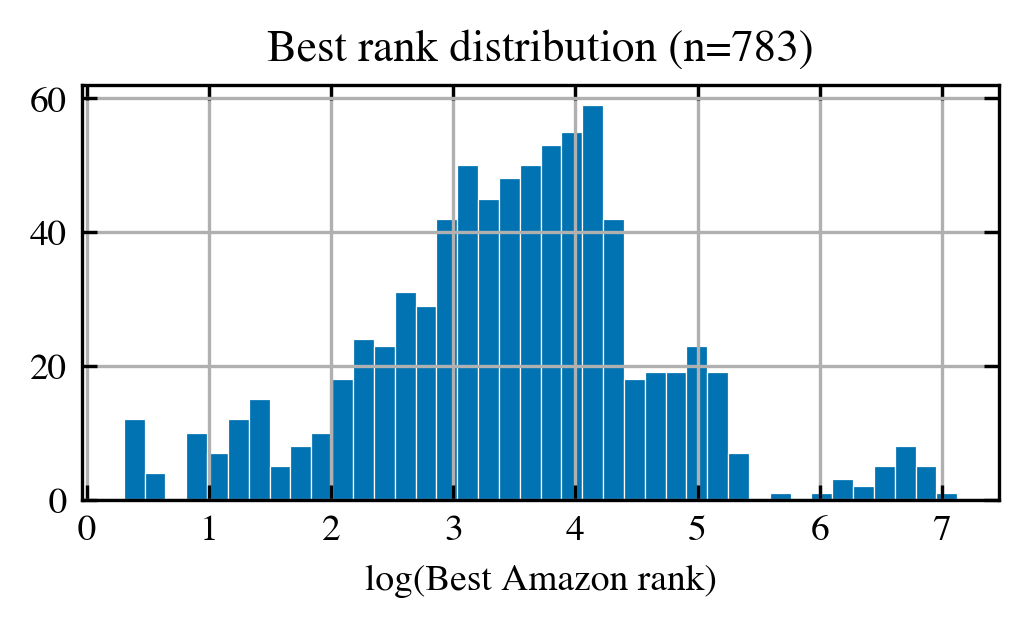

In [13]:
fig, ax = plt.subplots()
np.log10(canon['rank_best'].dropna() + 1).hist(
    ax=ax, bins=40, color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
ax.set_xlabel('log(Best Amazon rank)')
ax.set_title(f'Best rank distribution (n={n_rank:,})')
save_fig('02_rank_best_distribution.png', paths.FIGURES_DIR)
plt.show()

## Step 5 — UCSD Book Graph Enrichment (ISBN-13)
Streams 2.36M-row file and returns only rows matching GoodBooks ISBN-13s.  
Provides `publisher`, `ucsd_format`, `ucsd_language_code`, `ucsd_num_pages`, and  
a long description used to fill gaps where GoodBooks description is empty.

In [7]:
isbn13_set = set(canon['isbn13'].dropna())
ucsd = load_ucsd_filtered(isbn13_set)
print(f'UCSD enrichment rows: {len(ucsd)}')

canon = canon.merge(ucsd, on='isbn13', how='left')
n_ucsd = int(canon['publisher'].notna().sum())
print(f'Publisher attached: {n_ucsd:,} / {len(canon):,} ({n_ucsd/len(canon):.1%})')

gb_desc_missing = canon['description'].isna() | (canon['description'].str.strip() == '')
ucsd_desc_avail = canon['ucsd_description'].notna() & (canon['ucsd_description'].str.strip() != '')
filled = int((gb_desc_missing & ucsd_desc_avail).sum())
canon.loc[gb_desc_missing & ucsd_desc_avail, 'description'] = \
    canon.loc[gb_desc_missing & ucsd_desc_avail, 'ucsd_description']
print(f'Descriptions filled from UCSD: {filled:,}')
canon.drop(columns=['ucsd_description'], inplace=True)

UCSD: streamed 964 matching rows, deduplicating…
UCSD enrichment rows: 964
Publisher attached: 964 / 10,000 (9.6%)
Descriptions filled from UCSD: 5


## Step 6 — NYT Bestsellers (ISBN-13 → title+author fallback)
**Primary outcome label**: `nyt_bestseller` (binary), plus `nyt_best_rank` and `nyt_weeks_on_list`.

Source: Post45 dataset, 60k weekly rows → aggregated to 7,431 unique books.  
Only 58% have an OCLC ISBN, and those ISBNs are hardcover-edition specific, so  
ISBN-13 matching alone would capture ≤1% of GoodBooks. Title+author is the main route.

In [8]:
nyt_raw = load_nyt_bestsellers()
nyt = agg_nyt_bestsellers(nyt_raw)
print(f'NYT raw: {len(nyt_raw):,} weekly rows → {len(nyt):,} unique books')
print(f'ISBN-13 available for {nyt["primary_isbn13"].notna().sum():,} / {len(nyt):,} ({nyt["primary_isbn13"].notna().mean():.0%})')

# ── Pass 1: ISBN-13 ────────────────────────────────────────────────────────────
nyt_isbn = nyt[nyt['primary_isbn13'].notna()][[
    'primary_isbn13', 'nyt_bestseller', 'nyt_best_rank', 'nyt_weeks_on_list'
]]
canon = join_on_isbn13(
    canon, nyt_isbn,
    base_isbn13_col='isbn13', right_isbn13_col='primary_isbn13',
    right_cols=['primary_isbn13', 'nyt_bestseller', 'nyt_best_rank', 'nyt_weeks_on_list'],
)
n_isbn = int(canon['nyt_bestseller'].notna().sum())
print(f'After ISBN-13: {n_isbn:,} matched')

# ── Pass 2: title+author for books still unmatched ────────────────────────────
unmatched_mask = canon['nyt_bestseller'].isna()
nyt_ta = nyt[['title', 'author', 'nyt_bestseller', 'nyt_best_rank', 'nyt_weeks_on_list']].rename(columns={
    'nyt_bestseller': '_nyt_b', 'nyt_best_rank': '_nyt_r', 'nyt_weeks_on_list': '_nyt_w'
})
filled = join_on_title_author(
    canon.loc[unmatched_mask, ['book_id', 'title', 'authors']],
    nyt_ta,
    base_title_col='title', base_author_col='authors',
    right_title_col='title', right_author_col='author',
    right_cols=['title', 'author', '_nyt_b', '_nyt_r', '_nyt_w'],
)[['book_id', '_nyt_b', '_nyt_r', '_nyt_w']]
canon = canon.merge(filled, on='book_id', how='left')
for src, dst in [('_nyt_b', 'nyt_bestseller'), ('_nyt_r', 'nyt_best_rank'), ('_nyt_w', 'nyt_weeks_on_list')]:
    canon[dst] = canon[dst].fillna(canon[src])
    canon.drop(columns=[src], inplace=True)

n_total = int(canon['nyt_bestseller'].notna().sum())
canon['nyt_bestseller'] = canon['nyt_bestseller'].fillna(0).astype(int)
print(f'After title+author: {n_total:,} total (+{n_total - n_isbn:,} new)')
print(f'\nNYT bestsellers in GoodBooks-10k: {canon["nyt_bestseller"].sum():,} ({canon["nyt_bestseller"].mean():.1%})')

NYT raw: 60,386 weekly rows → 7,431 unique books
ISBN-13 available for 4,328 / 7,431 (58%)
ISBN-13 join: 70/10000 rows matched (0.7%)
After ISBN-13: 70 matched
Title+author join: 962/9930 rows matched (9.7%)
After title+author: 1,032 total (+962 new)

NYT bestsellers in GoodBooks-10k: 1,032 (10.3%)


In [9]:
# Sanity check: well-known NYT titles should be labelled
known = ['Da Vinci Code', 'Gone Girl', 'Harry Potter', 'Hunger Games', 'The Firm', 'Pelican Brief']
canon[canon['title'].str.contains('|'.join(known), case=False, na=False)][
    ['title', 'authors', 'nyt_bestseller', 'nyt_best_rank', 'nyt_weeks_on_list']
].head(12)

,title,authors,nyt_bestseller,nyt_best_rank,nyt_weeks_on_list
0,"The Hunger Games (The Hunger Games, #1)",[Suzanne Collins],0,NaN,NaN
1,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","[J.K. Rowling, Mary GrandPré]",0,NaN,NaN
14,"Catching Fire (The Hunger Games, #2)",[Suzanne Collins],0,NaN,NaN
15,"Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)","[J.K. Rowling, Mary GrandPré, Rufus Beck]",0,NaN,NaN
16,"Mockingjay (The Hunger Games, #3)",[Suzanne Collins],0,NaN,NaN
17,"Harry Potter and the Order of the Phoenix (Harry Potter, #5)","[J.K. Rowling, Mary GrandPré]",0,NaN,NaN
19,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","[J.K. Rowling, Mary GrandPré]",0,NaN,NaN
20,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","[J.K. Rowling, Mary GrandPré]",0,NaN,NaN
21,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","[J.K. Rowling, Mary GrandPré]",0,NaN,NaN
22,"The Da Vinci Code (Robert Langdon, #2)",[Dan Brown],0,NaN,NaN


## Step 7 — Books Into Movies (title+author)
**Secondary outcome label**: `adapted_to_screen` (binary).

`book_title` is filled only when it differs from the movie title;  
we coalesce `book_title → movie_title` to form the join key.

In [10]:
movies_raw = load_books_into_movies()
print(f'Books Into Movies: {len(movies_raw)} rows')

movies = movies_raw.copy()
movies['adapted_to_screen'] = 1
movies['join_title'] = movies['book_title'].where(movies['book_title'].notna(), movies['movie_title'])
movies_dedup = movies[['join_title', 'author', 'adapted_to_screen']].drop_duplicates(subset=['join_title', 'author'])

canon = join_on_title_author(
    canon, movies_dedup,
    base_title_col='title', base_author_col='authors',
    right_title_col='join_title', right_author_col='author',
    right_cols=['join_title', 'author', 'adapted_to_screen'],
)
canon['adapted_to_screen'] = canon['adapted_to_screen'].fillna(0).astype(int)
print(f'Books marked adapted: {canon["adapted_to_screen"].sum():,}')
canon[canon['adapted_to_screen'] == 1][['title', 'authors', 'nyt_bestseller', 'adapted_to_screen']].head(10)

Books Into Movies: 70 rows
Title+author join: 26/10000 rows matched (0.3%)
Books marked adapted: 26


,title,authors,nyt_bestseller,adapted_to_screen
73,The Glass Castle,[Jeannette Walls],0,1
158,It,[Stephen King],1,1
160,The Bell Jar,[Sylvia Plath],1,1
194,Ready Player One,[Ernest Cline],0,1
226,Wonder,[R.J. Palacio],0,1
291,"Where'd You Go, Bernadette",[Maria Semple],1,1
332,How the Grinch Stole Christmas!,[Dr. Seuss],0,1
372,Bel Canto,[Ann Patchett],0,1
400,Before I Fall,[Lauren Oliver],0,1
557,The Tale of Peter Rabbit,[Beatrix Potter],0,1


## Step 8 — Coverage Summary & Save

ISBN-10                              9,300 / 10,000  (93.0%) non-null
ISBN-13                              9,435 / 10,000  (94.3%) non-null
Amazon ASIN (any source)               817 / 10,000  (8.2%) non-null
Amazon rank history                    783 / 10,000  (7.8%) non-null
Amazon review count                    101 / 10,000  (1.0%) non-null
UCSD publisher                         964 / 10,000  (9.6%) non-null
Any description                      9,948 / 10,000  (99.5%) non-null
NYT bestseller (positive)            1,032 / 10,000  (10.3%) positive
Screen adaptation (positive)            26 / 10,000  (0.3%) positive
Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/02_canonical_coverage.png


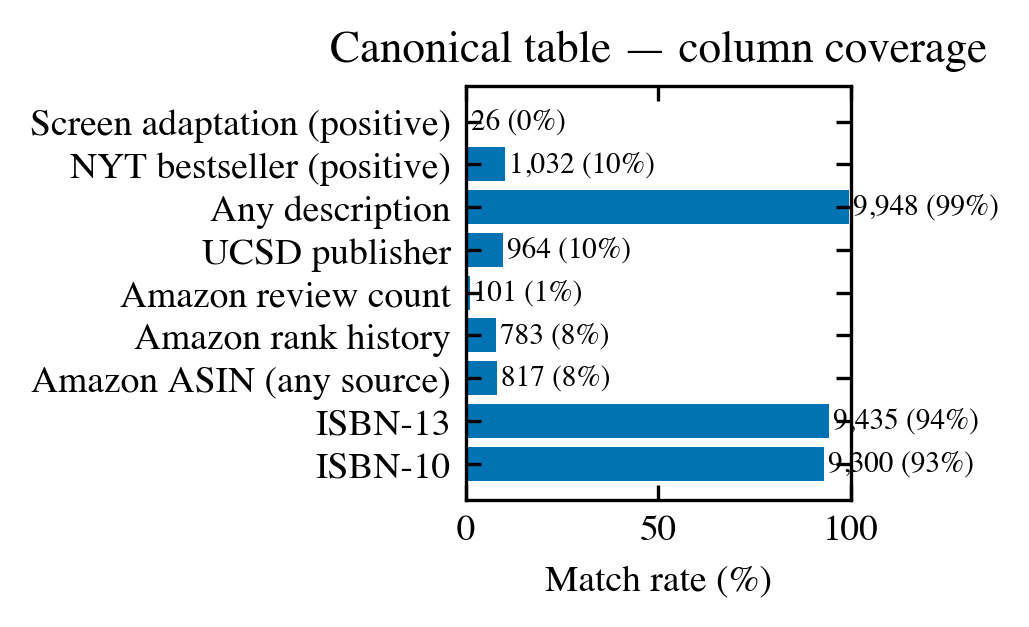

In [11]:
checks = [
    ('isbn10',               'ISBN-10'),
    ('isbn13',               'ISBN-13'),
    ('asin',                 'Amazon ASIN (any source)'),
    ('rank_best',            'Amazon rank history'),
    ('amazon_reviews_count', 'Amazon review count'),
    ('publisher',            'UCSD publisher'),
    ('description',          'Any description'),
    ('nyt_bestseller',       'NYT bestseller (positive)'),
    ('adapted_to_screen',    'Screen adaptation (positive)'),
]

binary_cols = {'nyt_bestseller', 'adapted_to_screen'}
labels, counts = [], []
for col, label in checks:
    if col not in canon.columns:
        continue
    n = int(canon[col].sum()) if col in binary_cols else int(canon[col].notna().sum())
    labels.append(label)
    counts.append(n)
    suffix = ' positive' if col in binary_cols else ' non-null'
    print(f'{label:35s}  {n:>5,} / {len(canon):,}  ({n/len(canon):.1%}){suffix}')

coverage_bar(labels, counts, total=len(canon), title='Canonical table — column coverage')
save_fig('02_canonical_coverage.png', paths.FIGURES_DIR)
plt.show()

In [12]:
assert len(canon) == 10_000, f'Row explosion: {len(canon)}'
out_path = paths.derived_path('canonical_books.csv')
canon.to_csv(out_path, index=False)
print(f'Saved {len(canon):,} rows × {len(canon.columns)} columns → {out_path}')
print('\nFinal schema:')
canon.dtypes

Saved 10,000 rows × 38 columns → /Users/dingshandeng/data_local/data_book/derived/canonical_books.csv

Final schema:


book_id                        int64
title                            str
authors                       object
original_publication_year    float64
language_code                    str
pages                        float64
description                      str
genres                        object
isbn10                           str
isbn13                           str
goodreads_book_id              int64
average_rating               float64
ratings_count                  int64
work_text_reviews_count        int64
ratings_1                      int64
ratings_2                      int64
ratings_3                      int64
ratings_4                      int64
ratings_5                      int64
asin                             str
amazon_avg_rating            float64
amazon_reviews_count         float64
amazon_price                 float64
amazon_num_sellers           float64
rank_best                    float64
rank_median                  float64
rank_latest                  float64
r